In [8]:
# Import necessary libraries
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Load iris dataset
iris = datasets.load_iris()

# Use petal width as the feature
X = iris["data"][:, 3:]

# Binary target: 1 if Virginica, else 0
Y = (iris["target"] == 2).astype(np.int32)

print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

Feature shape: (150, 1)
Target shape: (150,)


In [10]:
# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [11]:
# Create and train the logistic regression model
clf = LogisticRegression()

clf.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
# Predict on test data
Y_pred = clf.predict(X_test)

In [13]:
# Evaluate the model
print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 1.0

Confusion Matrix:
[[19  0]
 [ 0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
# Example prediction
example = clf.predict([[2.6]])

print("Prediction for petal width of 2.6:",
      "Virginica" if example[0] == 1 else "Not Virginica")

Prediction for petal width of 2.6: Virginica


In [15]:
# Create a range of petal width values
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)

# Get probabilities for each class
Y_prob = clf.predict_proba(X_new)

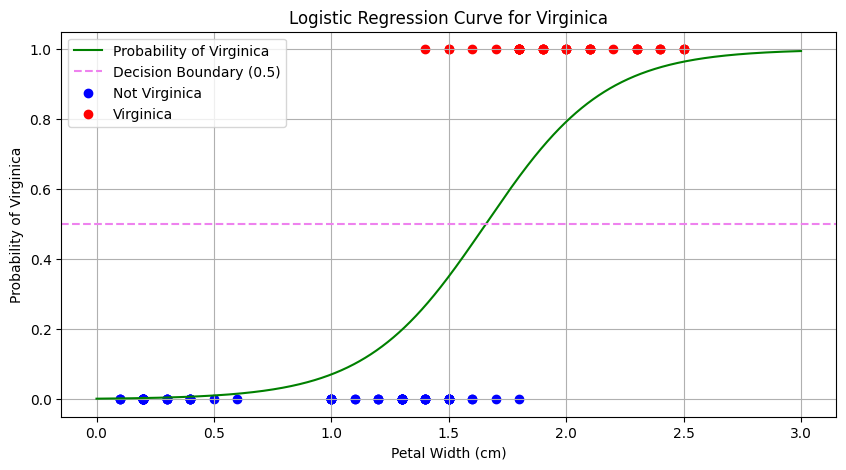

In [16]:
# Plot logistic regression curve
plt.figure(figsize=(10,5))

plt.plot(X_new, Y_prob[:,1], "g-", label="Probability of Virginica")

plt.axhline(0.5, color='violet', linestyle='--', label="Decision Boundary (0.5)")

plt.scatter(X_train[Y_train==0], Y_train[Y_train==0],
            color="blue", label="Not Virginica")

plt.scatter(X_train[Y_train==1], Y_train[Y_train==1],
            color="red", label="Virginica")

plt.xlabel("Petal Width (cm)")
plt.ylabel("Probability of Virginica")
plt.title("Logistic Regression Curve for Virginica")

plt.legend()
plt.grid()

plt.show()